<div style="background: linear-gradient(135deg, #0f1117 0%, #1a1d27 50%, #0f1117 100%); border: 1px solid #34d399; padding: 32px; border-radius: 12px; text-align: center; margin-bottom: 20px;">
<h1 style="color: #34d399; font-size: 2.2em; margin: 0 0 8px 0;">Python Tutorial — Advanced</h1>
<p style="color: #a0aec0; font-size: 1.1em; margin: 0; text-align: center;">Sections 22–29 | File I/O, CSV, JSON, Regex, Imports, Matplotlib, Pandas, PEP8</p>
</div>


## Table of Contents

- Section 22 — File I/O
- Section 23 — CSV Module
- Section 24 — JSON Files
- Section 25 — Regular Expressions
- Section 26 — Imports & the Math Module
- Section 27 — Matplotlib & scipy
- Section 28 — Pandas
- Section 29 — PEP 8 — The Style Guide


<div style="background: linear-gradient(135deg, #1a1d27 0%, #2a2d3a 100%); border-left: 5px solid #34d399; padding: 20px 24px; border-radius: 8px; margin: 12px 0;">
<h2 style="color: #34d399; margin: 0 0 4px 0; font-size: 1.4em;">Section 22 — File I/O</h2>
<p style="color: #a0aec0; margin: 0; font-size: 0.9em;">Read/write files safely and efficiently</p>
</div>


A context manager is a construct that automatically handles setup and cleanup — with open(...) opens a file and guarantees it's closed when the block ends, even if an error occurs.

with open(...) as f: opens the file and
guarantees it is closed when the block finishes — even if your code
crashes halfway through. Always use this pattern instead of calling f.close() manually.


In [1]:
rt_values = []

with open("rt_data.txt", "r") as f:
    for line in f:
        clean = line.strip()       # remove \n at end of each line
        if clean:                          # skip blank lines
            rt_values.append(float(clean))

print(rt_values)


[412.0, 378.5, 445.2, 390.1]


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Reading</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Read a text file line by line</span>
</div>


In [2]:
rt_values = [412.0, 378.5, 445.2, 390.1]
average = sum(rt_values) / len(rt_values)

with open("rt_data.txt", "w") as f:
    f.write(f"Average: {average}\n")


⚠️ The example below is a separate code snippet — if run after the one above, it would overwrite the file.


In [3]:
# Write each RT on its own line with a blank line between (Exercise 48)
with open("rt_data.txt", "w") as f:
    for rt in rt_values:
        f.write(str(rt) + "\n\n")   # \n\n = blank line between values


| Mode | Meaning |
| --- | --- |
| "r" | Read — file must already exist |
| "w" | Write — creates new or overwrites existing file |
| "a" | Append — adds to end without overwriting |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Writing</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Write results to a file</span>
</div>


In [4]:
# Always handle FileNotFoundError when opening files
def read_file_safe(filepath):
    try:
        with open(filepath, "r", encoding="utf-8") as f:
            return f.read()
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return None
    except PermissionError:
        print(f"No permission to read: {filepath}")
        return None

content = read_file_safe("rt_data.txt")
if content is not None:
    print(f"Read {len(content)} characters.")


Read 28 characters.


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Error Handling</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">FileNotFoundError & Robust File Access</span>
</div>


In [5]:
# writelines() — write a list of strings at once (no auto-newline!)
lines = ["P01,control,412\n", "P02,experimental,378\n", "P03,control,445\n"]
with open("participants.txt", "w") as f:
    f.writelines(lines)  # faster than looping write()

# readlines() — read all lines into a list
with open("participants.txt", "r") as f:
    all_lines = f.readlines()
print(f"Lines: {all_lines}")  # each line includes \n

# Strip newlines cleanly with a list comprehension
clean = [line.strip() for line in all_lines]
print(clean)

# Append a new participant without overwriting
with open("participants.txt", "a") as f:
    f.write("P04,experimental,401\n")

# Count lines in a file
with open("participants.txt", "r") as f:
    line_count = sum(1 for _ in f)  # memory-efficient count
print(f"Total lines: {line_count}")


Lines: ['P01,control,412\n', 'P02,experimental,378\n', 'P03,control,445\n']
['P01,control,412', 'P02,experimental,378', 'P03,control,445']
Total lines: 4


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">writelines / readlines</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Writing & Reading Lines Efficiently</span>
</div>


<div style="background: linear-gradient(135deg, #1a1d27 0%, #2a2d3a 100%); border-left: 5px solid #34d399; padding: 20px 24px; border-radius: 8px; margin: 12px 0;">
<h2 style="color: #34d399; margin: 0 0 4px 0; font-size: 1.4em;">Section 23 — CSV Module</h2>
<p style="color: #a0aec0; margin: 0; font-size: 0.9em;">Work with CSV data using Python's csv module</p>
</div>


Most psychology tools export your data as a CSV file (Comma-Separated Values). Qualtrics surveys, Pavlovia experiments, SPSS datasets,
and EEG / eye-tracking systems all produce CSV. A CSV file is simply
a text file where each row is one record (e.g., one participant) and
the columns are separated by commas.

Python’s built-in csv module reads and
writes these files safely — it handles commas inside quoted
fields, different delimiters (tab, semicolon), and encoding issues
without you needing to split lines by hand.

| Task | Tool to use |
| --- | --- |
| Read rows as plain lists | csv.reader |
| Read rows as dicts (column name as key) | csv.DictReader |
| Write rows from lists | csv.writer |
| Write rows from dicts | csv.DictWriter |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Concept</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Why CSV matters in psychology research</span>
</div>


In [6]:
import os, csv
# Create sample data files used in this section
if not os.path.exists('participants.csv'):
    with open('participants.csv', 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['participant_id', 'condition', 'rt_ms'])
        w.writerow(['P01', 'control', '412'])
        w.writerow(['P02', 'experimental', '378'])
        w.writerow(['P03', 'control', '445'])
        w.writerow(['P04', 'experimental', '390'])
        w.writerow(['P05', 'control', '421'])
    print("Created sample participants.csv")

if not os.path.exists('eeg_data.txt'):
    with open('eeg_data.txt', 'w') as f:
        for _ in range(5):
            row = ' '.join([f'{__import__("random").uniform(0.1, 1.5):.4f}' for _ in range(8)])
            f.write(row + '\n')
    print("Created sample eeg_data.txt")

In [7]:
import csv

with open("participants.csv", "r") as f:
    reader = csv.reader(f)
    for row in reader:
        print(row)    # e.g. ['P01', 'control', '412']

# Space-separated — EEG files (PIP4)
with open("eeg_data.txt", "r") as f:
    reader = csv.reader(f, delimiter=' ', skipinitialspace=True)
    for row in reader:
        print(row)


['participant_id', 'condition', 'rt_ms']
['P01', 'control', '412']
['P02', 'experimental', '378']
['P03', 'control', '445']
['P04', 'experimental', '390']
['P05', 'control', '421']
['P06', 'experimental', '355']
['0.1390', '1.3849', '1.0018', '0.2960', '1.0203', '0.1868', '0.8245', '0.2016']
['0.5150', '0.6101', '0.3906', '0.1579', '0.8713', '0.9906', '0.1054', '0.6591']
['1.1033', '0.6042', '1.3716', '0.3064', '1.4559', '0.9992', '0.9047', '0.4949']
['0.8334', '0.4683', '1.4190', '0.1489', '1.1694', '0.3309', '0.1608', '0.8921']
['0.4958', '0.9555', '1.2509', '0.6282', '0.2310', '1.0587', '0.1114', '0.5256']


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">csv.reader</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Read rows as lists</span>
</div>


In [8]:
import csv

participant_ids, conditions, rt_values = [], [], []

with open("participants.csv", "r") as f:
    reader = csv.DictReader(f)    # first row becomes column keys
    for row in reader:
        participant_ids.append(row["participant_id"])
        conditions.append(row["condition"])
        rt_values.append(float(row["rt_ms"]))


⚠️ If you get a KeyError: 'rt_ms' when reading a CSV exported from Excel, the header may contain invisible BOM characters or extra spaces. Use row.get('rt_ms') instead of row['rt_ms'] , or open the file with encoding='utf-8-sig' to strip the BOM automatically.

Real data often has missing or placeholder values. Always guard before converting:


In [9]:
with open("participants.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        # Skip rows where rt_ms is empty or the placeholder 'NA'
        if row["rt_ms"] and row["rt_ms"] != 'NA':
            rt_values.append(float(row["rt_ms"]))


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">DictReader</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Access columns by name from the header row</span>
</div>


Use csv.writer to write lists of
data to a CSV file. Always open the file with newline="" to prevent extra blank
lines on Windows.


In [10]:
import csv

data = [
    ["participant_id", "condition", "rt_ms"],
    ["P01", "control", 412],
    ["P02", "experimental", 378]
]

# Write all rows at once
with open("participants.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerows(data)

# Append a single row
with open("participants.csv", "a", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["P03", "control", 445])


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Syntax/Methods</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Writing CSV — csv.writer</span>
</div>


If your data is in dictionaries, csv.DictWriter is the easiest way
to write it. You must specify the fieldnames (column headers)
first.


In [11]:
import csv

experiment_results = [
    {"participant_id": "P01", "condition": "control", "rt_ms": 412},
    {"participant_id": "P02", "condition": "experimental", "rt_ms": 378}
]

columns = ["participant_id", "condition", "rt_ms"]

with open("participants.csv", "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=columns)

    writer.writeheader()        # Writes the first row with column names
    writer.writerows(experiment_results) # Writes all the dictionaries


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Syntax/Methods</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Writing CSV — csv.DictWriter</span>
</div>


When CSV data contains commas or newlines, it must be quoted. The csv module handles this
automatically, but you can control the behavior.


In [12]:
import csv

# Data with commas inside the values
data = [["P01", "I felt calm, relaxed, and focused"]]

# Specify encoding="utf-8" to handle special characters (é, ñ, etc.)
with open("participants.csv", "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(
        f,
        quoting=csv.QUOTE_ALL,  # Quote every field
        quotechar='"'           # Use double quotes (default)
    )
    writer.writerows(data)


| Quoting Constant | Behavior |
| --- | --- |
| csv.QUOTE_MINIMAL | (Default) Only quotes fields containing the delimiter or quotechar. |
| csv.QUOTE_ALL | Quotes every single field, regardless of type. |
| csv.QUOTE_NONNUMERIC | Quotes all non-numeric fields. Converts unquoted fields to floats on read. |
| csv.QUOTE_NONE | Never quotes fields. Requires setting an escapechar . |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Reference/Comparison</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Quoting & Encoding</span>
</div>


<div style="background: linear-gradient(135deg, #1a1d27 0%, #2a2d3a 100%); border-left: 5px solid #34d399; padding: 20px 24px; border-radius: 8px; margin: 12px 0;">
<h2 style="color: #34d399; margin: 0 0 4px 0; font-size: 1.4em;">Section 24 — JSON Files</h2>
<p style="color: #a0aec0; margin: 0; font-size: 0.9em;">Serialize, store, and validate JSON data</p>
</div>


JSON (JavaScript Object Notation) is the most
common format for data exchange on the web and between programs.
Python's json module lets you
read and write JSON files — they look almost identical to Python
dictionaries and lists.

| JSON type | Python equivalent | Example |
| --- | --- | --- |
| object {} | dict | {"id": "P01"} |
| array [] | list | [1, 2, 3] |
| string | str | "hello" (always double quotes) |
| number | int / float | 42 , 3.14 |
| boolean | bool | true / false (lowercase in JSON!) |
| null | None | null |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Concept</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">What is JSON?</span>
</div>


json.dumps() converts Python →
JSON string. json.loads() converts JSON string
→ Python. (The "s" = string.)


In [13]:
import json

# Python dict → JSON string
participant = {"id": "P01", "condition": "control", "rt_ms": 412, "valid": True, "notes": None}
json_str = json.dumps(participant)
print(type(json_str))  # <class 'str'>
print(json_str)

# Pretty-print with indentation
pretty = json.dumps(participant, indent=2)
print(pretty)

# JSON string → Python dict
raw = '{"id": "P02", "condition": "experimental", "rt_ms": 378, "valid": false, "notes": null}'
parsed = json.loads(raw)
print(type(parsed))         # <class 'dict'>
print(parsed["id"])         # P02
print(parsed["valid"])     # False (Python bool, not JSON false)
print(parsed["notes"])     # None (Python None, not JSON null)


<class 'str'>
{"id": "P01", "condition": "control", "rt_ms": 412, "valid": true, "notes": null}
{
  "id": "P01",
  "condition": "control",
  "rt_ms": 412,
  "valid": true,
  "notes": null
}
<class 'dict'>
P02
False
None


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">json.dumps / json.loads</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Working with JSON Strings</span>
</div>


json.dump() writes Python → file. json.load() reads file → Python.
(No "s" = file.)


In [14]:
import json

# Experiment settings to save
config = {
    "study_name": "Stroop Task 2024",
    "version": "1.0.0",
    "n_participants": 30,
    "conditions": ["control", "experimental"],
    "debug": False
}

# WRITE: Python dict → JSON file
with open("config.json", "w") as f:
    json.dump(config, f, indent=2)

# READ: JSON file → Python dict
with open("config.json", "r") as f:
    loaded = json.load(f)

print(loaded["study_name"])   # Stroop Task 2024
print(loaded["conditions"])   # ['control', 'experimental']
print(type(loaded["conditions"]))  # list

# Modify and re-save
loaded["version"] = "1.1.0"
loaded["conditions"].append("baseline")
with open("config.json", "w") as f:
    json.dump(loaded, f, indent=2)
print("Updated config saved.")


Stroop Task 2024
['control', 'experimental']
<class 'list'>
Updated config saved.


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">json.dump / json.load</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Reading & Writing JSON Files</span>
</div>


Always handle the two most common JSON file errors: the file not
existing, and the file containing invalid JSON.


In [15]:
import json

def load_config(filepath):
    try:
        with open(filepath, "r") as f:
            return json.load(f)
    except FileNotFoundError:
        print(f"File not found: {filepath}")
        return {}  # return empty dict as safe default
    except json.JSONDecodeError as e:
        print(f"Invalid JSON in {filepath}: {e}")
        return {}

# Load from a file that does not exist
cfg = load_config("missing.json")
print("Config loaded:", cfg)

# Load from invalid JSON string (simulate)
try:
    bad = json.loads("{name: Alice}")  # missing quotes around key
except json.JSONDecodeError as e:
    print(f"JSONDecodeError: {e}")


File not found: missing.json
Config loaded: {}
JSONDecodeError: Expecting property name enclosed in double quotes: line 1 column 2 (char 1)


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Error Handling</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">FileNotFoundError & JSONDecodeError</span>
</div>


In [16]:
import json
# Simulate a participant dataset
dataset = {
    "participants": [
        {"id": "P01", "condition": "control",       "rt_ms": {"trial_1": 412, "trial_2": 398}},
        {"id": "P02", "condition": "experimental", "rt_ms": {"trial_1": 378, "trial_2": 360}},
    ]
}

# Save nested structure
with open("participants.json", "w") as f:
    json.dump(dataset, f, indent=2)

# Load and navigate the structure
with open("participants.json", "r") as f:
    db = json.load(f)

for p in db["participants"]:
    avg = sum(p["rt_ms"].values()) / len(p["rt_ms"])
    print(f"{p['id']} ({p['condition']}): avg RT = {avg:.1f} ms")


P01 (control): avg RT = 405.0 ms
P02 (experimental): avg RT = 369.0 ms


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Real World</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">JSON with Nested Data & Lists</span>
</div>


| Format | Best for | Python module |
| --- | --- | --- |
| JSON | Structured/nested data (configs, APIs, records with mixed types) | json |
| CSV | Tabular/flat data (spreadsheets, one row per record) | csv |
| Plain text | Logs, notes, unstructured content | open() |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Comparison</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">JSON vs CSV vs Plain Text</span>
</div>


<div style="background: linear-gradient(135deg, #1a1d27 0%, #2a2d3a 100%); border-left: 5px solid #34d399; padding: 20px 24px; border-radius: 8px; margin: 12px 0;">
<h2 style="color: #34d399; margin: 0 0 4px 0; font-size: 1.4em;">Section 25 — Regular Expressions</h2>
<p style="color: #a0aec0; margin: 0; font-size: 0.9em;">Pattern matching with regular expressions</p>
</div>


Regex uses special characters to define patterns.


In [17]:
# Character classes
# \d : Any digit (0-9)
# \w : Any word character (a-z, A-Z, 0-9, _)
# \s : Any whitespace (space, tab, newline)
# .  : Any character except newline

# Uppercase negates the class
# \D : Any NON-digit
# \W : Any NON-word character
# \S : Any NON-whitespace

# Quantifiers (how many times)
# *      : 0 or more times
# +      : 1 or more times
# ?      : 0 or 1 time (optional)
# {n}    : Exactly n times
# {n,m}  : Between n and m times

# Anchors
# ^ : Start of string
# $ : End of string

# Custom sets
# [aeiou] : Any vowel
# [0-9a-f]: Any hex digit
# [^abc]  : Anything EXCEPT a, b, or c
      


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Syntax</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Pattern Syntax</span>
</div>


Regular expressions (regex) are a powerful
mini-language for pattern matching in text. Instead of just
searching for an exact word, you can search for patterns like
"any text that starts with P followed by exactly two digits"
(a participant ID).

In Python, you use the built-in re module.


In [18]:
import re

# Search for a participant ID pattern (P followed by 2 digits)
text = "Session log: P01 completed, P02 timed out, P03 completed."

match = re.search(r"P\d{2}", text)

if match:
    print("First match:", match.group())  # First match: P01

# Find ALL participant IDs mentioned in the log
all_ids = re.findall(r"P\d{2}", text)
print(all_ids)  # ['P01', 'P02', 'P03']
      


First match: P01
['P01', 'P02', 'P03']


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Concept</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">What are Regular Expressions?</span>
</div>


The re module provides several
functions depending on what you want to do.


In [19]:
import re
log = "Trial 1: P01 responded in 412 ms. Trial 2: P02 responded in 378 ms."

# re.search(): Finds the FIRST match anywhere in the string
match = re.search(r"P\d{2}", log)
if match:
    print(match.group())  # P01

# re.match(): Finds a match ONLY at the START of the string
match = re.match(r"Trial", log)
if match:
    print(match.group())   # Trial
print(re.match(r"P01", log))            # None (P01 is not at position 0)

# re.findall(): Returns a list of all matches
print(re.findall(r"P\d{2}", log))      # ['P01', 'P02']

# re.finditer(): Returns match objects with positions
for m in re.finditer(r"\d+ ms", log):
    print(f"RT found: '{m.group()}' at index {m.start()}")

# re.sub(): Search and replace (e.g. anonymise an old format)
cleaned = re.sub(r"P\d{2}", "[ANON]", log)
print(cleaned)

# re.split(): Split string by pattern
parts = re.split(r"\. ", log)   # split on sentence boundaries
print(parts)

# re.compile(): Precompile a pattern used many times (faster)
id_pattern = re.compile(r"P\d{2}")
print(id_pattern.findall(log))   # ['P01', 'P02']
      


P01
Trial
None
['P01', 'P02']
RT found: '412 ms' at index 26
RT found: '378 ms' at index 60
Trial 1: [ANON] responded in 412 ms. Trial 2: [ANON] responded in 378 ms.
['Trial 1: P01 responded in 412 ms', 'Trial 2: P02 responded in 378 ms.']
['P01', 'P02']


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Syntax</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">re Module Functions</span>
</div>


Parentheses () create capturing groups , allowing you to extract
specific parts of a match.


In [20]:
import re

# Extracting parts of a date
date_str = "Today is 2023-10-25."
match = re.search(r"(\d{4})-(\d{2})-(\d{2})", date_str)

if match:
    print("Full match:", match.group(0))  # 2023-10-25
    print("Year:", match.group(1))        # 2023
    print("Month:", match.group(2))       # 10
    print("Day:", match.group(3))         # 25

# Named groups make it even clearer: (?P<name>pattern)
pattern = r"(?P<year>\d{4})-(?P<month>\d{2})-(?P<day>\d{2})"
match = re.search(pattern, date_str)
if match:
    print(match.group("year"))  # 2023

# Simple email validation (Note: real email validation is much more complex)
email_pattern = r"^[a-zA-Z0-9_.+-]+@[a-zA-Z0-9-]+\.[a-zA-Z0-9-.]+$"
print(bool(re.match(email_pattern, "user@example.com")))  # True
print(bool(re.match(email_pattern, "invalid-email")))     # False
      


Full match: 2023-10-25
Year: 2023
Month: 10
Day: 25
2023
True
False


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Practice</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Groups & Practical Patterns</span>
</div>


| Target | Pattern | Example Match |
| --- | --- | --- |
| Integer | r"^-?\d+$" | "42", "-7" |
| Float | r"^-?\d+\.\d+$" | "3.14", "-0.001" |
| Date (YYYY-MM-DD) | r"^\d{4}-\d{2}-\d{2}$" | "2023-12-31" |
| Word boundary | r"\bword\b" | Matches "word" but not "sword" |
| Case insensitive | re.search(pat, text, re.IGNORECASE) | Matches "Cat", "CAT", "cat" |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Reference</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Common Patterns Reference</span>
</div>


<div style="background: linear-gradient(135deg, #1a1d27 0%, #2a2d3a 100%); border-left: 5px solid #34d399; padding: 20px 24px; border-radius: 8px; margin: 12px 0;">
<h2 style="color: #34d399; margin: 0 0 4px 0; font-size: 1.4em;">Section 26 — Imports & the Math Module</h2>
<p style="color: #a0aec0; margin: 0; font-size: 0.9em;">Imports, modules, and math/random/datetime libraries</p>
</div>


A module is a Python file that contains ready-made
functions and constants. Python ships with dozens of them
( built-in modules : math , csv , json , random , etc.).
A package is a collection of modules published by
someone else — you install it once with pip and then import it the same way. matplotlib and scipy are third-party packages.


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">import</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">How importing works</span>
</div>


In [21]:
import math

math.sqrt(16)     # 4.0   — square root (cleaner than 16 ** 0.5)
math.pi           # 3.14159… — the constant π
math.floor(3.9)   # 3     — round down
math.ceil(3.1)    # 4     — round up
math.pow(2, 10)   # 1024.0 — same as 2**10 but returns float
math.log(100, 10) # 2.0   — log base 10 (relevant for Fechner's Law)


2.0

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">math module</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Square roots, pi, rounding</span>
</div>


The random module provides
functions for generating random numbers and making random choices.


In [22]:
import random

# Random integers (inclusive on both ends)
# e.g. randomly assign a participant to a condition
conditions = ["control", "experimental"]
assigned = random.choice(conditions)
print(f"P01 assigned to: {assigned}")

# Random float between 0.0 and 1.0
noise = random.random()   # e.g. simulated measurement noise

# Counterbalanced trial order: shuffle in-place
trials = ["congruent", "congruent", "incongruent", "incongruent"]
random.shuffle(trials)
print(f"Trial order: {trials}")

# Pick k unique items without replacement
stimuli = ["red", "green", "blue", "yellow", "purple"]
subset = random.sample(stimuli, 3)

# Setting a seed = reproducible results (important for pre-registration)
random.seed(42)
print(random.randint(1, 100))  # Will always print 82 with seed 42


P01 assigned to: control
Trial order: ['incongruent', 'incongruent', 'congruent', 'congruent']
82


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Syntax/Methods</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">The random Module</span>
</div>


The datetime module helps you
work with dates, times, and time intervals.


In [23]:
import datetime

# Current date and time
now = datetime.datetime.now()
today = datetime.date.today()

# Date arithmetic using timedelta
one_week = datetime.timedelta(days=7)
deadline = today + one_week
print(f"Deadline is {deadline}")

# Formatting dates to strings (strftime)
# %Y=Year, %m=Month, %d=Day, %H=Hour, %M=Minute, %S=Second
formatted = now.strftime("%Y-%m-%d %H:%M:%S")
print(formatted)  # e.g., "2023-10-25 14:30:00"

# Parsing strings to dates (strptime)
date_str = "2000-01-01"
birth_date = datetime.datetime.strptime(date_str, "%Y-%m-%d").date()

# Calculate age
age_days = (today - birth_date).days
age_years = age_days // 365
print(f"You are roughly {age_years} years old.")


Deadline is 2026-03-14
2026-03-07 22:11:45
You are roughly 26 years old.


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Syntax/Methods</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">The datetime Module</span>
</div>


Any Python file ( .py ) is
automatically a module. You can import functions and variables
from one file into another to keep your code organized.


In [24]:
# File: my_helpers.py
def clean_data(text):
    return text.strip().lower()

# File: main.py (in the same folder)
import my_helpers

raw = "  HELLO WORLD  "
clean = my_helpers.clean_data(raw)
print(clean)  # "hello world"

# Alternatively, import specific functions:
from my_helpers import clean_data
clean2 = clean_data("  TEST  ")


ModuleNotFoundError: No module named 'my_helpers'

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Concept</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Creating Your Own Modules</span>
</div>


Python comes with a package manager called pip that lets you install
third-party libraries from the Python Package Index (PyPI).


In [25]:
# Run these commands in your terminal/command prompt, NOT in Python!

# Install a package
# pip install scipy

# See what's installed
# pip list
# pip show scipy

# Save your project's dependencies to a file
# pip freeze > requirements.txt

# Install all dependencies from a file
# pip install -r requirements.txt

# Create a virtual environment (keeps project dependencies separate)
# python -m venv myenv

# Activate the virtual environment (Windows)
# myenv\Scripts\activate

# Activate the virtual environment (Mac/Linux)
# source myenv/bin/activate

# Deactivate when done
# deactivate


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Syntax/Methods</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Installing Packages with pip</span>
</div>


<div style="background: linear-gradient(135deg, #1a1d27 0%, #2a2d3a 100%); border-left: 5px solid #34d399; padding: 20px 24px; border-radius: 8px; margin: 12px 0;">
<h2 style="color: #34d399; margin: 0 0 4px 0; font-size: 1.4em;">Section 27 — Matplotlib & scipy</h2>
<p style="color: #a0aec0; margin: 0; font-size: 0.9em;">Plotting and statistics with Matplotlib and scipy</p>
</div>


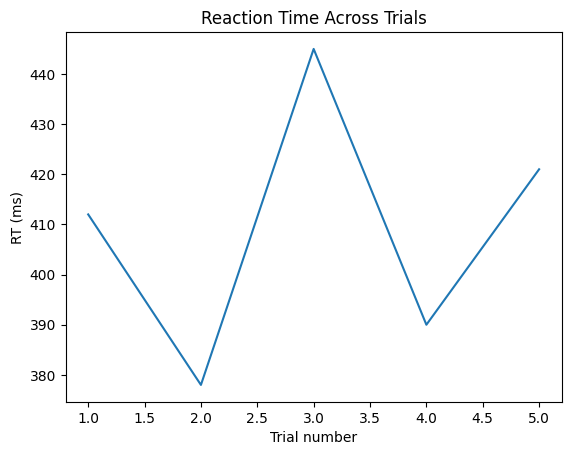

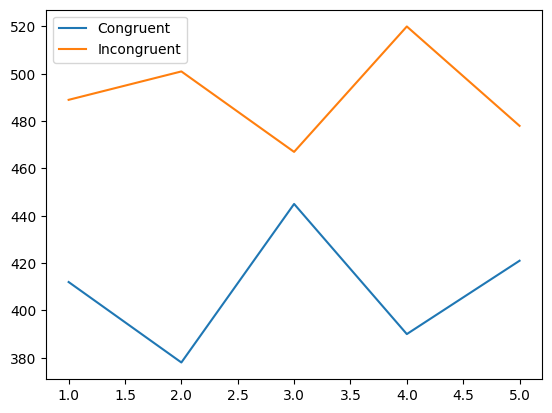

In [26]:
import matplotlib.pyplot as plt

trial          = [1, 2, 3, 4, 5]          # x-axis: trial number
rt_ms          = [412, 378, 445, 390, 421]  # y-axis: reaction time in milliseconds

plt.plot(trial, rt_ms)
plt.title("Reaction Time Across Trials")
plt.xlabel("Trial number")
plt.ylabel("RT (ms)")
plt.show()   # opens a window with the plot

# Two conditions on one plot
rt_congruent   = [412, 378, 445, 390, 421]  # Stroop congruent trials
rt_incongruent = [489, 501, 467, 520, 478]  # Stroop incongruent trials

plt.plot(trial, rt_congruent,   label="Congruent")
plt.plot(trial, rt_incongruent, label="Incongruent")
plt.legend()
plt.show()


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">matplotlib</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Plotting reaction time data</span>
</div>


Measures how strongly two channels move together. Creative EEG:
high correlation between frontal channels of both hemispheres.


In [27]:
import numpy as np

# Sample EEG channel data (used for correlation analysis)
np.random.seed(42)
channel_a = np.random.randn(100)         # 100 simulated EEG samples
channel_b = channel_a * 0.8 + np.random.randn(100) * 0.3  # correlated signal

In [28]:
from scipy.stats import pearsonr

# Both lists must be 1D and identical length
r, p = pearsonr(channel_a, channel_b)
print(f"Correlation: r = {r:.3f}")
print(f"P-value:     p = {p:.3f}")


Correlation: r = 0.925
P-value:     p = 0.000


| r value | Meaning |
| --- | --- |
| close to +1 | Strong positive correlation |
| close to 0 | No correlation |
| close to −1 | Strong negative correlation |
| p < 0.05 | Result is statistically significant |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">scipy.stats.pearsonr</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Pearson correlation (PIP4)</span>
</div>


| Mistake | Fix |
| --- | --- |
| print("RT = " + rt_ms) crashes (int) | print(f"RT = {rt_ms}") |
| range(1, n) misses a trial | Use range(n) for all n trials |
| plt.show() then plt.savefig('chart.png') | Call plt.savefig('chart.png') then plt.show() |
| pearsonr(group_a, group_b) with mismatched lengths | Ensure len(group_a) == len(group_b) first |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Common pitfalls</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Common pitfalls</span>
</div>


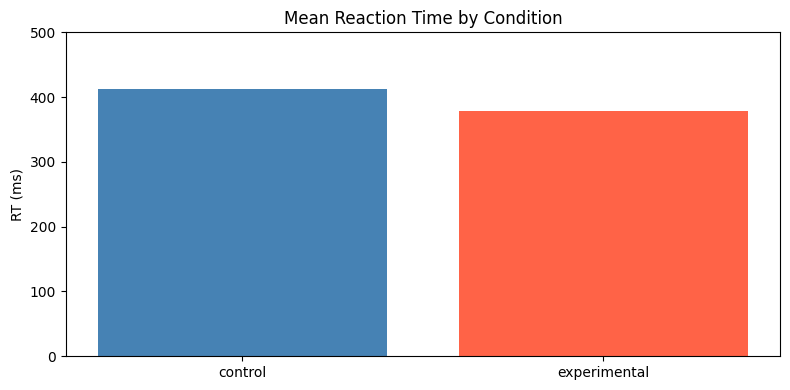

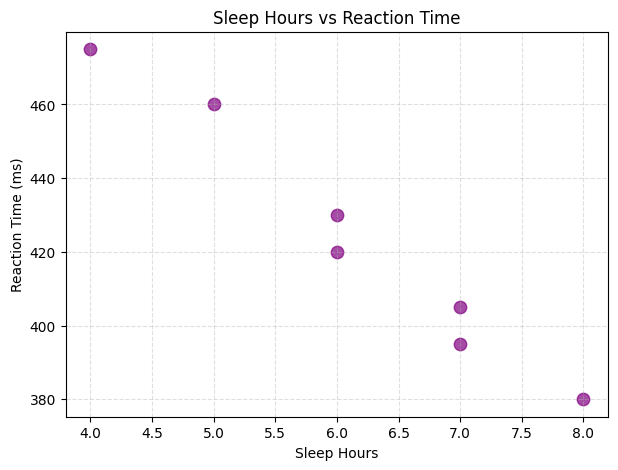

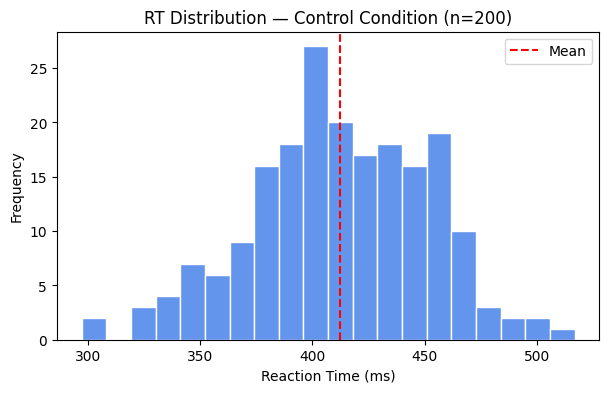

In [29]:
import matplotlib.pyplot as plt

# Bar chart — compare mean RT across conditions
conditions = ["control", "experimental"]
mean_rt     = [412, 378]
plt.figure(figsize=(8, 4))
plt.bar(conditions, mean_rt, color=["steelblue", "tomato"])
plt.title("Mean Reaction Time by Condition")
plt.ylabel("RT (ms)")
plt.ylim(0, 500)
plt.tight_layout()
plt.savefig("rt_bar.png", dpi=150)
plt.show()

# Scatter plot — show relationship between two variables
participant_id = ["P01","P02","P03","P04","P05","P06","P07"]
sleep_hours = [6, 7, 5, 8, 4, 7, 6]
rt_ms = [420, 395, 460, 380, 475, 405, 430]
plt.figure(figsize=(7, 5))
plt.scatter(sleep_hours, rt_ms, color="purple", s=80, alpha=0.7)
plt.xlabel("Sleep Hours")
plt.ylabel("Reaction Time (ms)")
plt.title("Sleep Hours vs Reaction Time")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

# Histogram — distribution of reaction times
import random
rt_data = [random.gauss(412, 40) for _ in range(200)]
plt.figure(figsize=(7, 4))
plt.hist(rt_data, bins=20, color="cornflowerblue", edgecolor="white")
plt.xlabel("Reaction Time (ms)")
plt.ylabel("Frequency")
plt.title("RT Distribution — Control Condition (n=200)")
plt.axvline(sum(rt_data)/len(rt_data), color="red", linestyle="--", label="Mean")
plt.legend()
plt.show()


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Chart Types</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">bar, scatter, hist, boxplot</span>
</div>


plt.subplots(rows, cols) creates a figure with multiple axes. Each axis is an independent
chart.


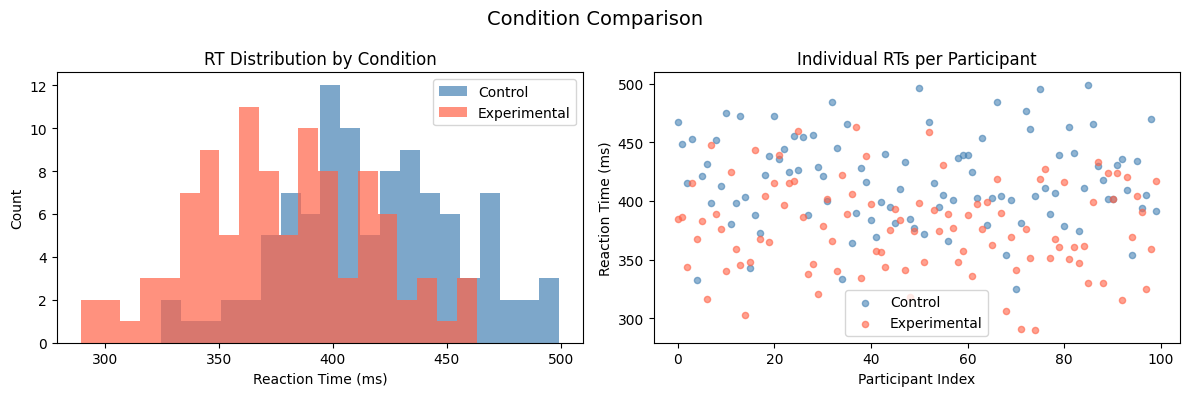

In [30]:
import matplotlib.pyplot as plt
import random

ctrl_rt = [random.gauss(412, 40) for _ in range(100)]
exp_rt  = [random.gauss(378, 40) for _ in range(100)]

# Create 1 row, 2 columns of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: histogram
ax1.hist(ctrl_rt, bins=20, color="steelblue", alpha=0.7, label="Control")
ax1.hist(exp_rt, bins=20, color="tomato", alpha=0.7, label="Experimental")
ax1.set_title("RT Distribution by Condition")
ax1.set_xlabel("Reaction Time (ms)")
ax1.set_ylabel("Count")
ax1.legend()

# Right panel: scatter
ax2.scatter(range(len(ctrl_rt)), ctrl_rt, s=20, alpha=0.6, color="steelblue", label="Control")
ax2.scatter(range(len(exp_rt)),  exp_rt,  s=20, alpha=0.6, color="tomato",    label="Experimental")
ax2.set_title("Individual RTs per Participant")
ax2.set_xlabel("Participant Index")
ax2.set_ylabel("Reaction Time (ms)")
ax2.legend()

fig.suptitle("Condition Comparison", fontsize=14)
plt.tight_layout()
plt.savefig("condition_comparison.png", dpi=150)
plt.show()


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Subplots</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Multiple Panels in One Figure</span>
</div>


| Parameter | Purpose | Typical value |
| --- | --- | --- |
| figsize=(w, h) | Figure size in inches | (10, 6) for wide, (6, 6) for square |
| dpi= | Dots per inch (resolution) | 100 screen, 300 publication |
| tight_layout() | Auto-adjust spacing between subplots | Call before savefig |
| savefig(path) | Save to file | PNG, PDF, SVG supported |


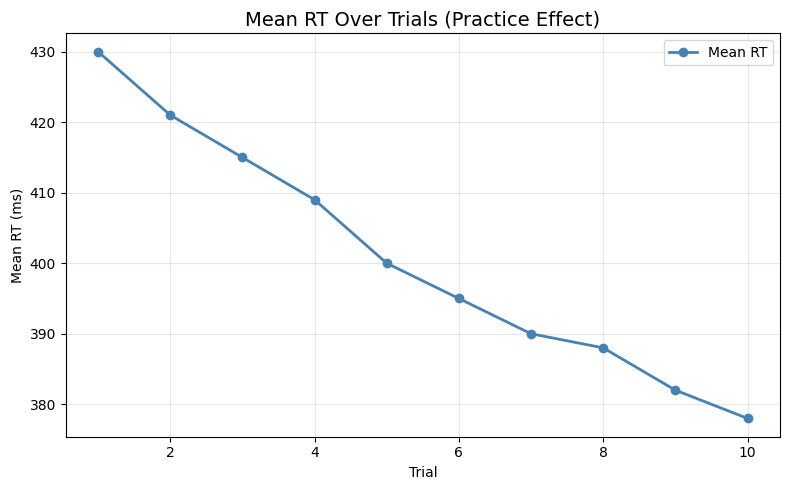

In [31]:
import matplotlib.pyplot as plt

trials = list(range(1, 11))   # 10 trials
mean_rt = [430, 421, 415, 409, 400, 395, 390, 388, 382, 378]

fig, ax = plt.subplots(figsize=(8, 5))  # width=8", height=5"
ax.plot(trials, mean_rt, marker="o", linewidth=2, color="steelblue", label="Mean RT")
ax.set_title("Mean RT Over Trials (Practice Effect)", fontsize=14)
ax.set_xlabel("Trial")
ax.set_ylabel("Mean RT (ms)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save in multiple formats
plt.savefig("rt_trials.png", dpi=150)
plt.savefig("rt_trials.pdf")          # vector (for print/report)
plt.show()


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">figsize & savefig</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Figure Size and Saving to File</span>
</div>


Seaborn is built on top of Matplotlib and makes
statistical plots much easier with better default aesthetics.
Install: pip3 install seaborn .
Import: import seaborn as sns .

<div style="background: #0d2818; border-left: 4px solid #34d399; padding: 12px 16px; border-radius: 6px; margin: 8px 0;">
<strong style="color: #34d399;">💡 Note</strong><br>
<span style="color: #e2e8f0;">The df variable used in the Seaborn examples below is a pandas DataFrame — covered in S28. This example shows what Seaborn code looks like; you'll be able to run it after completing S28.</span>
</div>

| Seaborn function | Use for |
| --- | --- |
| sns.histplot(data, kde=True) | Histogram with density curve (a smoothed histogram showing distribution shape) |
| sns.boxplot(data=df, x='condition', y='rt_ms') | Distribution by category |
| sns.scatterplot(data=df, x='sleep_hours', y='rt_ms', hue='condition') | Scatter with colour by group |
| sns.heatmap(corr_matrix, annot=True) | correlation matrix (table showing correlation between each pair of variables) |
| sns.pairplot(df) | pairplot (grid of scatterplots for all variable pairs) |
| sns.set_theme(style='darkgrid') | Set overall plot style |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Seaborn</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Statistical Plots with Seaborn</span>
</div>


<div style="background: linear-gradient(135deg, #1a1d27 0%, #2a2d3a 100%); border-left: 5px solid #34d399; padding: 20px 24px; border-radius: 8px; margin: 12px 0;">
<h2 style="color: #34d399; margin: 0 0 4px 0; font-size: 1.4em;">Section 28 — Pandas</h2>
<p style="color: #a0aec0; margin: 0; font-size: 0.9em;">Data analysis workflows with pandas</p>
</div>


In [32]:
# Install once in terminal:
# pip install pandas

# Import at top of every file — "pd" is the universal alias
import pandas as pd


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Setup</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Installation & import</span>
</div>


Pandas has two main structures. A Series is a
single labelled column (like a list with an index). A DataFrame is a table with rows and named
columns — think of it as a Python version of an Excel sheet.


In [33]:
# Series — one column
s = pd.Series([10, 20, 30], index=['a', 'b', 'c'])
s['b']       # 20 — access by label
s.iloc[1]         # 20 — access by position

# DataFrame — table
df = pd.DataFrame({
    'participant_id': ['P01', 'P02', 'P03'],
    'condition':      ['control', 'experimental', 'control'],
    'rt_ms':          [412, 378, 445]
})
print(df)
#   participant_id     condition  rt_ms
# 0            P01        control    412
# 1            P02  experimental    378
# 2            P03        control    445


  participant_id     condition  rt_ms
0            P01       control    412
1            P02  experimental    378
2            P03       control    445


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Core concepts</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Series vs DataFrame</span>
</div>


In [34]:
import csv, os
# Re-create clean participants.csv for the pandas section
# (earlier demo cells may have overwritten it with minimal data)
with open('participants.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['participant_id', 'condition', 'rt_ms'])
    w.writerow(['P01', 'control', '412'])
    w.writerow(['P02', 'experimental', '378'])
    w.writerow(['P03', 'control', '445'])
    w.writerow(['P04', 'experimental', '390'])
    w.writerow(['P05', 'control', '421'])
    w.writerow(['P06', 'experimental', '355'])
print("participants.csv ready for pandas demos")

participants.csv ready for pandas demos


In [35]:
# Read CSV (most common) — only this line actually runs; rest are cheat-sheet examples
df = pd.read_csv('participants.csv')

# Other common options (cheat-sheet — comment out as needed):
# df = pd.read_csv('participants.csv', sep=';')           # semicolon-separated
# df = pd.read_csv('participants.csv', header=None)       # no header row
# df = pd.read_csv('participants.csv', skiprows=2)        # skip first 2 rows
# df = pd.read_csv('participants.csv', index_col='participant_id')  # set index
# df = pd.read_excel('participants.xlsx', sheet_name='Sheet1')      # Excel (needs openpyxl)
# df = pd.read_csv('eeg_data.txt', sep=' ', header=None)            # space-separated
print(df.head())

  participant_id     condition  rt_ms
0            P01       control    412
1            P02  experimental    378
2            P03       control    445
3            P04  experimental    390
4            P05       control    421


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Reading & Writing</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">CSV, Excel, and more</span>
</div>


In [36]:
df.head(5)       # first 5 rows (default)
df.tail(3)       # last 3 rows
df.info()        # column names, types, non-null counts
df.describe()    # count, mean, std, min, max for numeric columns
df.shape         # (rows, columns) — e.g. (512, 8)
df.dtypes        # data type of each column
df.columns       # list of column names
df.index         # row labels
len(df)          # number of rows
df.value_counts('condition')  # frequency of each unique value


<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   participant_id  6 non-null      str  
 1   condition       6 non-null      str  
 2   rt_ms           6 non-null      int64
dtypes: int64(1), str(2)
memory usage: 276.0 bytes


condition
control         3
experimental    3
Name: count, dtype: int64

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Inspecting data</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">First thing to do with any new dataset</span>
</div>


In [37]:
# ── Select columns ──────────────────────────────────────────
df['participant_id']                # one column → returns Series
df[['participant_id', 'rt_ms']]    # multiple columns → returns DataFrame

# ── loc — label-based (use row/column names) ────────────────
df.loc[0]                  # row with index label 0
df.loc[0, 'participant_id']          # single cell: row 0, column 'participant_id'
df.loc[0:2, 'participant_id':'condition']  # slice rows AND columns by label
# NOTE: loc slicing is INCLUSIVE on both ends (unlike Python ranges)

# ── iloc — position-based (use integer positions) ───────────
df.iloc[0]                 # first row (by position)
df.iloc[0, 1]              # row 0, column 1
df.iloc[:3, :2]            # first 3 rows, first 2 columns
df.iloc[-1]                # last row


participant_id             P06
condition         experimental
rt_ms                      355
Name: 5, dtype: object

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Selecting data</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">[], loc, iloc — the three ways</span>
</div>


In [38]:
# Basic filter — get rows where rt_ms < 400
df[df['rt_ms'] < 400]

# Multiple conditions — use & (and), | (or), ~ (not for Series — do NOT use Python's 'not' here)
df[(df['rt_ms'] < 400) & (df['condition'] == 'control')]
df[(df['participant_id'] == 'P01') | (df['participant_id'] == 'P02')]

# isin — match against a list of values
df[df['participant_id'].isin(['P01', 'P03'])]

# query() — cleaner syntax for simple filters
df.query('rt_ms < 400 and condition == "control"')

# String filters
df[df['participant_id'].str.startswith('P')]
df[df['participant_id'].str.contains('0')]


,participant_id,condition,rt_ms
0,P01,control,412
1,P02,experimental,378
2,P03,control,445
3,P04,experimental,390
4,P05,control,421
5,P06,experimental,355


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Filtering</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Boolean indexing — selecting rows that meet a condition</span>
</div>


In [39]:
# Detect
df.isna()            # True/False table of missing values
df.isna().sum()       # count of NaN per column
df['rt_ms'].isna()     # True/False for one column

# Drop rows/columns with NaN
df.dropna()                       # drop any row with at least one NaN
df.dropna(subset=['rt_ms'])         # only drop if 'rt_ms' is NaN
df.dropna(axis=1)                  # drop columns that have any NaN

# Fill NaN with a value
df.fillna(0)                      # replace all NaN with 0
df['rt_ms'].fillna(df['rt_ms'].mean())  # fill with column average
df.ffill()          # forward fill (copy previous value)


,participant_id,condition,rt_ms
0,P01,control,412
1,P02,experimental,378
2,P03,control,445
3,P04,experimental,390
4,P05,control,421
5,P06,experimental,355


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Missing data</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">NaN — detecting, removing, filling</span>
</div>


In [7]:
# Add a new column
df['valid'] = df['rt_ms'] < 500          # boolean column
df['rt_z'] = df['rt_ms'] / df['rt_ms'].std()         # computed column

# Rename columns
df_renamed = df.rename(columns={'rt_ms': 'reaction_time'})  # avoid mutating df

# Delete a column
df_no_rtz = df.drop(columns=['rt_z'])  # use df_no_rtz to avoid mutating df

# Delete rows by index label
df_dropped = df.drop(index=[0, 2])   # use df_dropped to avoid mutating df

# Change column data type
# df['rt_ms'] = df['rt_ms'].astype(float)  # already float after read_csv
df['participant_id'] = df['participant_id'].astype(str)


NameError: name 'df' is not defined

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Columns</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Adding, modifying, and deleting</span>
</div>


In [6]:
df.sort_values('rt_ms')                       # ascending (default)
df.sort_values('rt_ms', ascending=False)      # descending
df.sort_values(['condition', 'rt_ms'])               # sort by multiple columns
df.sort_index()                                # sort by row index
df.reset_index(drop=True, inplace=True)       # reset to 0,1,2,… after filtering/sorting


NameError: name 'df' is not defined

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Sorting</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Sorting</span>
</div>


GroupBy splits the table into groups by a column, applies a
function to each group, and combines results. Think of it as a
pivot table.


In [5]:
# Single aggregation
df.groupby('condition')['rt_ms'].mean()    # mean rt_ms for each condition
df.groupby('condition').size()             # count participants in each group

# Multiple aggregations at once
df.groupby('condition')['rt_ms'].agg(['mean', 'min', 'max', 'count'])

# Group by multiple columns
df.groupby(['condition', 'participant_id'])['rt_ms'].mean()

# Common aggregation functions: sum, mean, median, min, max, count, std, var


NameError: name 'df' is not defined

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">GroupBy & aggregation</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Split → apply → combine</span>
</div>


apply() runs a function on each
element, row, or column. Define a plain function and pass it
to apply() — easier to read and test.


In [4]:
# define a plain function — easy to read
def rt_label(x):
    if x < 400: return 'fast'
    elif x < 450:
        return 'moderate'
    else:
        return 'slow'

# apply the function — runs rt_label on every value in the column
df['rt_category'] = df['rt_ms'].apply(rt_label)

# apply row-wise (axis=1) — access multiple columns
df['summary'] = df.apply(
    lambda row: f"{row['participant_id']} ({row['condition']})", axis=1
)


NameError: name 'df' is not defined

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">apply() & lambda</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Custom operations on every row or column</span>
</div>


In [3]:
df1 = pd.DataFrame({'participant_id':['P01','P02','P03'], 'condition':['control','experimental','control']})
df2 = pd.DataFrame({'participant_id':['P01','P02','P03'], 'rt_ms':[412,378,445]})

# merge — combine two DataFrames on a shared column
pd.merge(df1, df2, on='participant_id')                  # keeps only rows where participant_id matches in both tables
pd.merge(df1, df2, on='participant_id', how='left')     # keeps all rows from df1, fills gaps with NaN where df2 has no match
pd.merge(df1, df2, on='participant_id', how='outer')    # keeps all rows from both tables, fills gaps with NaN

# concat — stack DataFrames vertically or horizontally
pd.concat([df1, df2])                        # stack rows (axis=0, default)
pd.concat([df1, df2], axis=1)              # join side by side (axis=1)


NameError: name 'pd' is not defined

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Merging & joining</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Combining DataFrames</span>
</div>


In [2]:
df['participant_id'].str.upper()           # "P01", "P02", …
df['participant_id'].str.lower()           # "p01", "p02", …
df['participant_id'].str.len()             # length of each string
df['participant_id'].str.strip()           # remove leading/trailing whitespace
df['condition'].str.replace('control', 'ctrl') # replace in every value
df['participant_id'].str.split(' ')        # split each value into a list
df['participant_id'].str[0]                # first character of each string


NameError: name 'df' is not defined

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">String operations</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">.str accessor — apply string methods to a whole column</span>
</div>


In [1]:
df['rt_ms'].mean()      # average
df['rt_ms'].median()    # middle value
df['rt_ms'].std()       # standard deviation
df['rt_ms'].var()       # variance
df['rt_ms'].min()       # minimum
df['rt_ms'].max()       # maximum
df['rt_ms'].sum()       # total
df['rt_ms'].count()     # non-NaN count
df['rt_ms'].corr(df['condition'].map({'control': 0, 'experimental': 1}))  # Pearson correlation between two columns
df.corr(numeric_only=True)               # full correlation matrix of all numeric columns


NameError: name 'df' is not defined

<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Statistics</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Built-in numeric methods</span>
</div>


Pandas has a built-in .plot() wrapper around
matplotlib — for quick visualisations you don't need to import
matplotlib separately (though you still need plt.show() ).


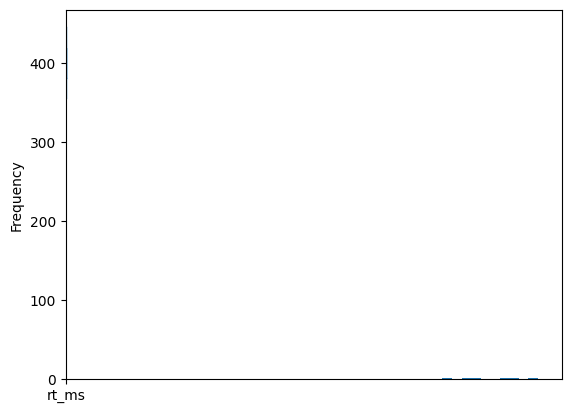

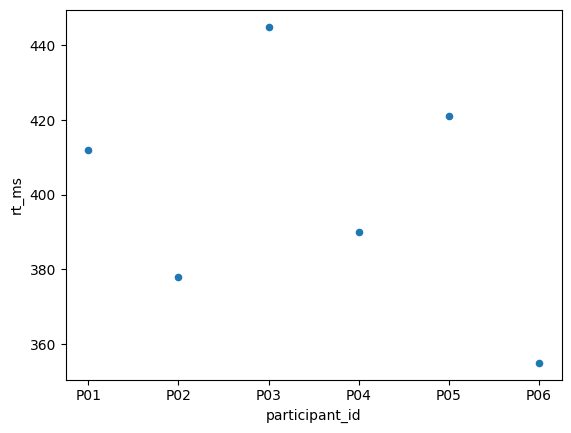

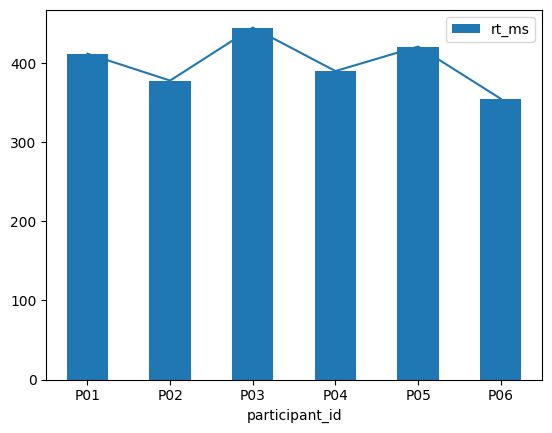

In [47]:
import matplotlib.pyplot as plt

df['rt_ms'].plot(kind='hist', bins=10)    # histogram
df['rt_ms'].plot(kind='box')              # boxplot
df.plot(x='participant_id', y='rt_ms', kind='scatter')  # scatter plot
df.plot(kind='bar', x='participant_id', y='rt_ms')   # bar chart
df['rt_ms'].plot(kind='line')             # line chart
plt.show()


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Plotting</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Quick charts directly from a DataFrame</span>
</div>


| Mistake | Fix |
| --- | --- |
| Modifying a slice: df[df.rt_ms<400]['rt_ms'] = 400 | Use df.loc[df.rt_ms<400, 'rt_ms'] = 400 — direct assignment |
| Forgot parentheses in filter: df[df.rt_ms<400 & df.condition=='control'] | df[(df.rt_ms<400) & (df.condition== 'control' )] |
| Changes not saved: df.dropna() | df = df.dropna() or add inplace=True |
| df['col'] vs df[['col']] | Single brackets → Series. Double brackets → DataFrame. Matters for merges. |
| Index not reset after filter/sort | Call df.reset_index(drop=True, inplace=True) |
| loc slicing is inclusive, iloc is exclusive | df.loc[0:2] gives rows 0,1,2. df.iloc[0:2] gives rows 0,1. |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Common pitfalls</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Common pitfalls</span>
</div>


pivot_table() summarises data
by aggregating values across two dimensions (rows and columns),
similar to pivot tables in Excel.

NumPy is a numerical computing library that pandas uses internally — you'll rarely call it directly, but import numpy as np is the conventional alias.


In [48]:
import pandas as pd
import numpy as np

data = {
    "participant_id": ["P01","P01","P02","P02","P03","P03"],
    "condition":   ["control","experimental","control","experimental","control","experimental"],
    "rt_ms":       [412,398,378,365,445,430],
    "session":     ["A","A","B","B","A","A"]
}
df = pd.DataFrame(data)

# pivot_table: rows=participant_id, cols=condition, values=rt_ms, aggfunc=mean
pivot = df.pivot_table(
    index="participant_id",
    columns="condition",
    values="rt_ms",
    aggfunc="mean"   # also: sum, count, max, min, np.median
)
print(pivot)

# Add margins (totals row/col)
pivot_margins = df.pivot_table(
    index="participant_id", columns="condition", values="rt_ms",
    aggfunc="mean", margins=True, margins_name="Average"
)
print(pivot_margins)

# After pivot_table: reset_index() makes participant_id a regular column
flat = pivot.reset_index()
print(flat)
print(flat.columns.tolist())


condition       control  experimental
participant_id                       
P01               412.0         398.0
P02               378.0         365.0
P03               445.0         430.0
condition          control  experimental     Average
participant_id                                      
P01             412.000000    398.000000  405.000000
P02             378.000000    365.000000  371.500000
P03             445.000000    430.000000  437.500000
Average         411.666667    397.666667  404.666667
condition participant_id  control  experimental
0                    P01    412.0         398.0
1                    P02    378.0         365.0
2                    P03    445.0         430.0
['participant_id', 'control', 'experimental']


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">pivot_table</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Pivot Tables</span>
</div>


Wide format : each condition is a separate column
(one row per participant). Long format : one row per
(participant, condition) pair. melt() converts wide → long —
required by many statistical and plotting functions.


In [49]:
import pandas as pd

# Wide format: one column per condition
wide = pd.DataFrame({
    "participant_id": ["P01", "P02", "P03"],
    "control_rt":  [412, 378, 445],
    "exp_rt":      [398, 365, 430],
})
print("Wide:")
print(wide)

# melt: wide → long
long = wide.melt(
    id_vars="participant_id",      # columns to keep as identifiers
    var_name="condition",    # name for the new category column
    value_name="rt_ms"     # name for the values column
)
print("\nLong:")
print(long)

# Long format is required for grouped analysis
print("\nMean per condition (from long format):")
print(long.groupby("condition")["rt_ms"].mean())


Wide:
  participant_id  control_rt  exp_rt
0            P01         412     398
1            P02         378     365
2            P03         445     430

Long:
  participant_id   condition  rt_ms
0            P01  control_rt    412
1            P02  control_rt    378
2            P03  control_rt    445
3            P01      exp_rt    398
4            P02      exp_rt    365
5            P03      exp_rt    430

Mean per condition (from long format):
condition
control_rt    411.666667
exp_rt        397.666667
Name: rt_ms, dtype: float64


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">melt</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Reshaping: Wide → Long with melt()</span>
</div>


After groupby().agg() , the
group key becomes the DataFrame index. reset_index() promotes it back
to a regular column, which is needed for further operations,
plotting, or merging.


In [50]:
import pandas as pd

data = {
    "participant_id": ["P01","P02","P01","P02","P03","P03"],
    "condition": ["control","control","experimental","experimental","control","experimental"],
    "rt_ms":   [412, 378, 398, 365, 445, 430]
}
df = pd.DataFrame(data)

# groupby returns 'participant_id' as index
grouped = df.groupby("participant_id")["rt_ms"].agg(["mean", "max", "min"])
print("After groupby (participant_id is the index):")
print(grouped)
print("Index:", grouped.index.tolist())

# reset_index: promotes index back to a column
flat = grouped.reset_index()
print("\nAfter reset_index (participant_id is a column again):")
print(flat)
print("Columns:", flat.columns.tolist())

# Now you can filter, sort, or merge on 'participant_id' column
top = flat[flat["mean"] >= flat["mean"].median()]
print("\nAbove-median performers:")
print(top)


After groupby (participant_id is the index):
                 mean  max  min
participant_id                 
P01             405.0  412  398
P02             371.5  378  365
P03             437.5  445  430
Index: ['P01', 'P02', 'P03']

After reset_index (participant_id is a column again):
  participant_id   mean  max  min
0            P01  405.0  412  398
1            P02  371.5  378  365
2            P03  437.5  445  430
Columns: ['participant_id', 'mean', 'max', 'min']

Above-median performers:
  participant_id   mean  max  min
0            P01  405.0  412  398
2            P03  437.5  445  430


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">reset_index</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">reset_index() After groupby</span>
</div>


<div style="background: linear-gradient(135deg, #1a1d27 0%, #2a2d3a 100%); border-left: 5px solid #34d399; padding: 20px 24px; border-radius: 8px; margin: 12px 0;">
<h2 style="color: #34d399; margin: 0 0 4px 0; font-size: 1.4em;">Section 29 — PEP 8 — The Style Guide</h2>
<p style="color: #a0aec0; margin: 0; font-size: 0.9em;">Style conventions for readable Python (PEP 8)</p>
</div>


PEP 8 is Python’s official style guide. It defines how to format
code so it’s readable and consistent — not for the computer, but for humans
reading it later (including you). Well-styled code is easier to debug, easier
to share, and looks professional.


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Concept</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Why PEP 8 matters</span>
</div>


snake_case means lowercase words joined by underscores. PascalCase means each word is capitalised with no underscores.
A constant is a value you treat as fixed (you don’t change it).

| What | Rule | Example |
| --- | --- | --- |
| Variables & functions | snake_case — lowercase words joined by underscores | reaction_time , calculate_mean |
| Constants | UPPER_SNAKE_CASE — all caps with underscores | MAX_TRIALS , DEFAULT_RT |
| Classes | PascalCase — each word capitalised, no underscores | ParticipantData |
| Private/internal | Prefix with underscore | _helper , _cache |

Most of your code as a beginner will use snake_case for variables and functions.


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Naming</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Conventions</span>
</div>


| Do ✅ | Don't ❌ |
| --- | --- |
| def process(rt): → 4-space indent inside | mixing tabs and spaces |
| spam(ham[1], {key: 2}) | spam( ham[ 1], { key: 2} ) (spaces inside brackets) |
| if x == 4: print(x, y) | if x == 4 : print(x , y) (space before colon/comma) |
| def f(x, y=0): (no spaces around = in keyword args) | def f(x, y = 0): |
| i = i + 1 (spaces around binary operators) | i=i+1 |


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Whitespace</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Indentation & spacing</span>
</div>


Use one import per line at the top of the file, grouped in order:
(1) standard library ( import os ),
(2) third-party ( import pandas as pd ),
(3) local/project files. Never use from module import * — it makes it impossible to know where names come from.


In [51]:
# ✅ Good
import os
import sys

import pandas as pd
import matplotlib.pyplot as plt

# ❌ Bad
import os, sys
from pandas import *


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Imports</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Grouped and readable</span>
</div>


- 2 blank lines before and after top-level functions and classes
- 1 blank line between methods inside a class


In [52]:
EXPERIMENT_NAME = "Stroop Task"   # module-level constant


def load_participants(filepath):
    """Return a list of participant IDs from a CSV file."""
    participants = []
    with open(filepath) as f:
        for line in f:
            participants.append(line.strip())
    return participants


def compute_mean_rt(rt_values):
    """Return the mean of a list of reaction times."""
    return sum(rt_values) / len(rt_values)


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Blank lines</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Give structure to files</span>
</div>


| Instead of… | Write this ✅ |
| --- | --- |
| if greeting == True: | if greeting: |
| if greeting == False: | if not greeting: |
| if len(results) == 0: | if not results: |
| if len(results) > 0: | if results: |
| type(rt) is type(1) | isinstance(rt, int) |

Python reads naturally — if results: reads as
“if there are results,” which is clearer than checking length.


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Idioms</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Booleans & sequences</span>
</div>


Before (bad style):


In [53]:
import random,math
RT=[]
def calcMean(l):
  s=0
  for i in l:
    s+=i
  return s/len(l)
for i in range(5):
  RT.append(random.randint(350,500))
print(calcMean(RT))


423.8


After (PEP 8):


In [54]:
import math
import random

MAX_TRIALS = 5
rt_ms = []

def calculate_mean(values):
    total = 0
    for value in values:
        total += value
    return total / len(values)

for _ in range(MAX_TRIALS):
    rt_ms.append(random.randint(350, 500))

print(calculate_mean(rt_ms))


424.2


<div style="margin: 20px 0 8px 0; padding: 8px 14px; background: #13162a; border-left: 3px solid #34d399; border-radius: 4px;">
<span style="color: #6ee7b7; font-weight: 600; font-size: 1.05em;">Before & After</span>
<span style="color: #6b7280; font-size: 0.85em; margin-left: 10px;">Same psychology script</span>
</div>
